In [69]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm

from Utils import Notebook, tex, gph, sgn, nm, ds
from petc_simulation import closed_loop_setm, open_loop
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LaTeX has been enabled for text rendering.


### Definição da Planta

In [70]:
experiment_config_filename = 'experiment-2'

with open(f"experiment/{experiment_config_filename}.json", encoding='utf-8') as f:
  config = json.load(f)

sim_duration = config['simulation_duration']
sim_step = config.get("simulation_step", 1e-4)
timepts = np.arange(0, sim_duration + sim_step, sim_step)

plant = ds.StateSpace(data=config["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [71]:
%%skip

x0 = np.array([[1.0], [-1.0]], dtype=np.float32)
plant_output, time_history, signal_control, _, _ = open_loop(
    x0, config, u_constant=0.0)

Cell skipped (unconditional).


In [72]:
%%skip

fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

y = plant_output
t = time_history

x_norm = np.linalg.norm(y, axis=0)
xnorm_f, xnorm_ul = nm.format_magnitudes(x_norm)

_ = gph.plot(
    axs['x'], t, x_norm,
    xlabel='$t$', x_unit='s',  x_use_prefixes=True,
    ylabel=r'$\|x(t)\|$',
    cfg={**cfg,
         'axis': {**cfg['axis']},
         'limits': {'x_min': 0, 'x_max': t[-1]}, }
)

Cell skipped (unconditional).


### Projeto do Controlador e do ETM

In [84]:
plant_data = {
    'nx': plant.nx, 'nu': plant.nu, 'nρ': plant.n_rho, 'nw': plant.nw, 'nz': plant.nz,
    'ρ_bounds': plant.get_parameter_bounds(),
    'u_bar': plant.get_input_bounds()[0],
    'matrices_func': lambda ρi: plant.matrices_func(ρi),
}

design_params = config["design_params"]["dspetc"]

In [ ]:
def control_synthesis(
    plant_data: Dict[str, Any],
    design_params: Dict[str, float],
    eps: float = 1e-6,
    dtype=np.float32
):
  nx = plant_data['nx']
  nu = plant_data['nu']
  nρ = plant_data['nρ']
  ρ_bounds = plant_data['ρ_bounds']
  matrices_func = plant_data['matrices_func']

  h = design_params['h']
  υ = design_params['υ']

  Bnp = list(itertools.product([0, 1], repeat=nρ))
  Onx = np.zeros((nx, nx), dtype=dtype)

  # Plant matrices
  A, B = {}, {}
  for i in Bnp:
    ρi = [ρ_bounds[idx][i[idx]] for idx in range(nρ)]
    mats = matrices_func(ρi)
    A[i] = cp.Parameter((nx, nx), value=mats['A'].astype(dtype))
    B[i] = cp.Parameter((nx, nu), value=mats['B'].astype(dtype))

  e = nm.get_e(5*[nx])
  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i].astype(dtype))

  # Variables
  Ptil = cp.Variable((nx, nx), PSD=True)
  Mtil = cp.Variable((2*nx, 2*nx), PSD=True)
  Q1til = cp.Variable((nx, nx), symmetric=True)
  Q2til = cp.Variable((nx, nx))
  Q3til = cp.Variable((nx, nx))
  S1til = cp.Variable((nx, nx), symmetric=True)
  S2til = cp.Variable((nx, nx))
  S3til = cp.Variable((nx, nx))
  Ktil = cp.Variable((nu, nx))

  Rtil = cp.Variable((nx, nx), PSD=True)
  Ξtil = cp.Variable((nx, nx), PSD=True)
  Ψtil = cp.Variable((nx, nx), PSD=True)
  X = cp.Variable((nx, nx))
  Ytil = cp.Variable((2*nx, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx], [Onx, 3*Rtil]])
  Fscr = e[1].T + υ*e[2].T + υ*e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1]-e[2]], [e[1]+e[2]-2*e[3]]])

  constraints = []

  def get_Θ(ω, i):
    Bscr = A[i] @ X @ e[1] + B[i] @ Ktil @ e[2] + \
        B[i] @ Ktil @ e[5] - X @ e[4]

    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  def get_Γ(i):
    Γ1_11 = get_Θ(0, i)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h, i)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_23 = np.zeros((2 * nx, nx))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  for i in nm.binary_set(nρ):
    LMI_SUM = {'0': 0., 'h': 0.}
    Λ0, Λh = get_Γ(i)
    LMI_SUM['0'] += Λ0
    LMI_SUM['h'] += Λh
    constraints += [LMI_SUM['0'] << -eps *
                    np.eye(LMI_SUM['0'].shape[0], dtype=dtype)]
    constraints += [LMI_SUM['h'] << -eps *
                    np.eye(LMI_SUM['h'].shape[0], dtype=dtype)]

  constraints += [Ψtil >> eps*np.eye(nx, dtype=dtype)]
  constraints += [Ξtil >> eps*np.eye(nx, dtype=dtype)]

  # Objective
  obj = cp.Minimize(cp.trace(Ξtil+Ψtil))
  prob = cp.Problem(obj, constraints)
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # Results
  design_results = None
  if prob.status not in ["infeasible", "unbounded"]:
    Xinv = np.linalg.inv(X.value.astype(dtype))
    Ξ = Xinv.T @ Ξtil.value.astype(dtype) @ Xinv
    Ψ = np.linalg.inv(Ψtil.value.astype(dtype))
    P = Xinv.T @ Ptil.value.astype(dtype) @ Xinv
    S2 = Xinv.T @ S2til.value.astype(dtype) @ Xinv

    K = Ktil.value.astype(dtype) @ Xinv

    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
  return design_results

In [74]:
Ξ = Ψ = K = L1 = P = γ = β = None
optimal_value = None

results = control_synthesis(plant_data, design_params)

Ξ, Ψ = results['etm']['Ξ'], results['etm']['Ψ']
K = results['controller']['K']
P, S2 = results['lyapunov']
optimal_value = results['optimal_value']

display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
display(Math(rf'P = {tex.mat2tex(P)}'))
display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [79]:
plant = ds.StateSpace(data=config["plant"], name='plant')
sim = ds.SimulationEngineOld()
sim.add_system(plant)

Xi, Psi = results['etm']['Ξ'], results['etm']['Ψ']
K = results['controller']['K']

design_params = config["design_params"]["dspetc"]
u_bar = plant.get_input_bounds()
sampler = ds.Sampler(Ts=design_params['h'], time_source=lambda: sim.t)

setm_kwargs = {'Ξ': Xi, 'Ψ': Psi}
setm = DSPETC.SETM(**setm_kwargs)
sim.add_system(setm)
rho_bounds = plant.get_parameter_bounds()

x0 = np.array([[1.0], [-1.0]], dtype=np.float32)
x0 = np.array(x0, dtype=np.float32).reshape(-1, 1)

sim.get_system('plant').set_initial_state(x0)
setm.x_hat = x0.copy()
setm.xm = x0.copy()
sim.setup_clock(duration=7.5, dt=1e-4)
sim.reset_clock()
sampler.reset()

event_time = []
uc = [[0.0]]
signal_control = []

while sim.advance_clock():
  signal_control += [uc]
  default_inputs = {'plant': {'u1': uc}}

  with sim.step(default_inputs=default_inputs) as step:
    transmit = False
    if sampler.check():
      setm.xm = plant.states.copy()
      transmit = setm.triggering_condition() or (sim.t == 0.0)
    if not transmit:
      continue
    rho_hat = plant.evaluate_parameters(sim.t)
    setm.x_hat = setm.xm.copy()
    event_time += [sim.t]
    uc = K @ setm.x_hat

signal_control = np.squeeze(np.array(signal_control))
if signal_control.ndim == 1:
  signal_control = signal_control[np.newaxis, :]
else:
  signal_control = signal_control.T
event_time = np.array(event_time)
sim.finalize_history()
plant_output = sim.output_history['plant']
time_history = sim.time_history

In [80]:
inter_event_time = DSPETC.get_iet(event_time[1:])

std_iet = np.std(inter_event_time)
cv_iet = std_iet / np.mean(inter_event_time)
event_rate = len(inter_event_time) / timepts[-1]

print("Estado Inicial: ", y[0].reshape(-1))
print("Número de amostras dos estados: ", int(t[-1] / 0.1e-3))
print("Número de transmissões de estados realizados: ",
      len(inter_event_time))
print("Menor IET Obtido: ", min(inter_event_time))
print("Máximo IET Obtido: ", max(inter_event_time))
print("Média do Intervalos de Tempo entre Eventos: ", np.mean(
      inter_event_time))

print("Desvio-padrão dos IETs: ", std_iet)
print("Coeficiente de variação dos IETs: ", cv_iet)
print("Taxa média de acionamentos: ", event_rate, "eventos/s")

Estado Inicial:  [ 9.9989998e-01  9.9979997e-01  9.9969995e-01 ... -1.4987888e+05
 -1.4989208e+05 -1.4990528e+05]
Número de amostras dos estados:  200000
Número de transmissões de estados realizados:  13
Menor IET Obtido:  0.34800005
Máximo IET Obtido:  1.132
Média do Intervalos de Tempo entre Eventos:  0.55300003
Desvio-padrão dos IETs:  0.21505024
Coeficiente de variação dos IETs:  0.38887924
Taxa média de acionamentos:  0.65 eventos/s


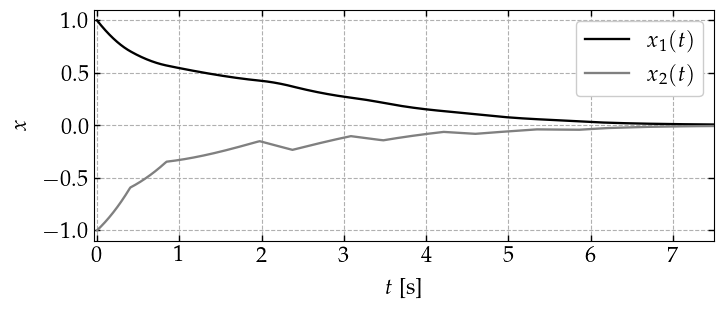

In [83]:
fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time_history,
    [plant_output[0], plant_output[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=fr'$x$',
    cfg={**cfg, 'style': {'color': ['black', 'gray']}},
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

### MTD aplicado ao ETC

In [ ]:
import itertools
import numpy as np
import cvxpy as cp
import warnings
from typing import Dict, Any, List


def control_synthesis_mtd_probabilistico(
    plant_data: Dict[str, Any],
    design_params: Dict[str, float],
    mtd_data: Dict[str, Any],
    eps: float = 1e-6,
    dtype=np.float32
):
  # Silencia avisos internos de tradução de backend do CVXPY
  warnings.filterwarnings('ignore', category=UserWarning)

  nx = plant_data['nx']
  nu = plant_data['nu']
  nρ = plant_data['nρ']
  ρ_bounds = plant_data['ρ_bounds']
  matrices_func = plant_data['matrices_func']

  h = float(design_params['h'])
  υ = float(design_params['υ'])
  # Peso para regularização de gamma
  beta = float(design_params.get('beta', 0.01))
  # Fator de diversidade matricial
  factor_diff = float(design_params.get('delta_diff', 1.2))
  # Peso da penalização da folga
  weight_slack = float(design_params.get('weight_slack', 100.0))

  # MTD Configurations (Probabilidades e Geometria Ativas)
  M = mtd_data['M']          # Número de modos do MTD (int)
  R = mtd_data['R']          # Número de regiões elipsoidais (int)
  W = mtd_data['W'].astype(dtype)  # Matriz de formato do elipsoide (nx x nx)
  c = mtd_data['c']          # Vetor com os raios crescentes (c[0]=0)
  pi = mtd_data['pi']        # Tensor de probabilidades (M x M x R)

  Bnp = list(itertools.product([0, 1], repeat=nρ))
  Onx = np.zeros((nx, nx), dtype=dtype)

  # Plant matrices
  A, B = {}, {}
  for i in Bnp:
    ρi = [ρ_bounds[idx][i[idx]] for idx in range(nρ)]
    mats = matrices_func(ρi)
    A[i] = cp.Parameter((nx, nx), value=mats['A'].astype(dtype))
    B[i] = cp.Parameter((nx, nu), value=mats['B'].astype(dtype))

  e = nm.get_e(5*[nx])
  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i].astype(dtype))

  # --- Variáveis Comuns ---
  Mtil = cp.Variable((2*nx, 2*nx), PSD=True)
  Q1til = cp.Variable((nx, nx), symmetric=True)
  Q2til = cp.Variable((nx, nx))
  Q3til = cp.Variable((nx, nx))
  S1til = cp.Variable((nx, nx), symmetric=True)
  S2til = cp.Variable((nx, nx))
  S3til = cp.Variable((nx, nx))
  Ktil = cp.Variable((nu, nx))
  Rtil = cp.Variable((nx, nx), PSD=True)
  X = cp.Variable((nx, nx))
  Ytil = cp.Variable((2*nx, e[1].shape[1]))

  # --- Variáveis Dependentes do Modo ---
  Ptil = [cp.Variable((nx, nx), PSD=True) for _ in range(M)]
  Ξtil = [cp.Variable((nx, nx), PSD=True) for _ in range(M)]
  Ψtil = [cp.Variable((nx, nx), PSD=True) for _ in range(M)]
  gamma = [cp.Variable(nonneg=True) for _ in range(M)]

  # CORREÇÃO: Variável de folga para absorver a contradição estocástica na origem
  slack_jump = cp.Variable(nonneg=True)

  # --- Multiplicadores do S-Procedimento ---
  mu1 = {}
  mu2 = {}
  for p in range(M):
    for r in range(R):
      mu1[(p, r)] = cp.Variable(nonneg=True)
      mu2[(p, r)] = cp.Variable(nonneg=True)

  Rcal = cp.bmat([[Rtil, Onx], [Onx, 3*Rtil]])
  Fscr = e[1].T + float(υ)*e[2].T + float(υ)*e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1]-e[2]], [e[1]+e[2]-2*e[3]]])

  constraints = []

  # --- Bloco 1: Fluxo Contínuo LPV ---
  def get_Θ(ω, i, p):
    Bscr = A[i] @ X @ e[1] + B[i] @ Ktil @ e[2] + \
        B[i] @ Ktil @ e[5] - X @ e[4]

    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]

    return nm.He(e[1].T @ Ptil[p] @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil[p] @ e[5] - \
        Θ1 - float(ω) * Θ2 - float(h) * e[3].T @ Q1til @ e[3] + \
        float(h - ω) * Θ3 + float(h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        float(h - ω) * Θ4

  def get_Γ(i, p):
    Γ1_11 = get_Θ(0, i, p)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil[p]

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h, i, p)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_23 = np.zeros((2 * nx, nx))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil[p]

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  for i in nm.binary_set(nρ):
    for p in range(M):
      Λ0, Λh = get_Γ(i, p)
      constraints += [Λ0 << -eps * np.eye(Λ0.shape[0], dtype=dtype)]
      constraints += [Λh << -eps * np.eye(Λh.shape[0], dtype=dtype)]

  # --- Bloco 2: Saltos Estocásticos Não-Homogêneos ---
  for p in range(M):
    constraints += [Ψtil[p] >> eps * np.eye(nx, dtype=dtype)]
    constraints += [Ξtil[p] >> eps * np.eye(nx, dtype=dtype)]
    constraints += [gamma[p] >= eps]

    for r in range(R):
      P_next_expected = 0
      gamma_next_expected = 0
      for q in range(M):
        prob = float(pi[p, q, r])
        P_next_expected = P_next_expected + prob * Ptil[q]
        gamma_next_expected = gamma_next_expected + prob * gamma[q]

      # LMI de Salto Matricial Markoviana com S-Procedimento
      matrix_jump_lmi = P_next_expected - \
          Ptil[p] + (mu1[(p, r)] - mu2[(p, r)]) * W
      constraints += [matrix_jump_lmi << -eps * np.eye(nx, dtype=dtype)]

      # CORREÇÃO DEFINITIVA: Trocado de <= 0 para <= slack_jump para destravar o colapso
      scalar_jump_lmi = gamma_next_expected - \
          gamma[p] - mu1[(p, r)] * float(c[r]) + \
          mu2[(p, r)] * float(c[r+1])
      constraints += [scalar_jump_lmi <= slack_jump]

  # --- Restrições de Diversidade Matricial Rígida (Cenário A) ---
  for p in range(M - 1):
    constraints += [Ψtil[p] - float(factor_diff)
                    * Ψtil[p+1] >> eps * np.eye(nx, dtype=dtype)]
    constraints += [Ξtil[p] - float(factor_diff)
                    * Ξtil[p+1] >> eps * np.eye(nx, dtype=dtype)]
    constraints += [Ptil[p] - float(factor_diff)
                    * Ptil[p+1] >> eps * np.eye(nx, dtype=dtype)]

  # --- Função Objetivo Multi-Modo Penalizada com o Slack ---
  obj_terms = []
  for p in range(M):
    obj_terms.append(cp.trace(Ξtil[p] + Ψtil[p]) + beta * gamma[p])

  # O solver tentará minimizar os traços e empurrar o slack_jump o mais próximo possível de zero
  obj = cp.Minimize(cp.sum(obj_terms) + weight_slack * slack_jump)

  prob = cp.Problem(obj, constraints)
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  design_results = None
  if prob.status not in ["infeasible", "unbounded"]:
    Xinv = np.linalg.inv(X.value.astype(dtype))
    K = Ktil.value.astype(dtype) @ Xinv
    S2 = Xinv.T @ S2til.value.astype(dtype) @ Xinv

    etm_modes_results = []
    lyapunov_modes_results = []
    gamma_modes_results = []

    for p in range(M):
      Ξ_p = Xinv.T @ Ξtil[p].value.astype(
          dtype) @ Xinv if Ξtil[p].value is not None else None
      Ψ_p = np.linalg.inv(Ψtil[p].value.astype(
          dtype)) if Ψtil[p].value is not None else None
      P_p = Xinv.T @ Ptil[p].value.astype(
          dtype) @ Xinv if Ptil[p].value is not None else None
      γ_p = gamma[p].value if gamma[p].value is not None else 0.0

      etm_modes_results.append({'Ξ': Ξ_p, 'Ψ': Ψ_p})
      lyapunov_modes_results.append(P_p)
      gamma_modes_results.append(γ_p)

    design_results = {
        'optimal_value': prob.value,
        'controller': {'K': K},
        'etm_modes': etm_modes_results,
        'lyapunov_modes': lyapunov_modes_results,
        'gamma_modes': gamma_modes_results,
        'S2': S2,
        'slack_jump': slack_jump.value  # Retorna o valor final da folga calculada
    }

  return design_results

In [305]:
import numpy as np
from datetime import datetime

# --- PARAMETRIZAÇÃO GERAL ---
M = 5  # Número de modos operacionais de ETM
R = 2  # Número de regiões elipsoidais concêntricas
SEED = 42  # Mude o Seed para gerar cenários completamente diferentes, ou mantenha para travar os números

# Inicializa o gerador pseudo-aleatório com o seed escolhido
rng = np.random.default_rng(SEED)

# ==============================================================================
# 1. GERAÇÃO AUTOMÁTICA E PSEUDO-ALEATÓRIA DE 'c'
# ==============================================================================
# O raio c[0] deve ser sempre 0.0. Geramos R valores aleatórios crescentes para o resto.
valores_aleatorios_c = rng.uniform(low=1.0, high=8.0, size=R)
# Garante que os raios são estritamente crescentes
passos_c = np.cumsum(valores_aleatorios_c)

c = [0.0] + list(passos_c)
# Exemplo se SEED=42, R=2: c pode resultar em [0.0, 1.83, 5.21] etc.

# ==============================================================================
# 2. GERAÇÃO AUTOMÁTICA E PSEUDO-ALEATÓRIA DO TENSOR 'pi'
# ==============================================================================
pi = np.zeros((M, M, R), dtype=np.float32)

for r in range(R):
  # Gera uma matriz de pesos aleatórios (M x M) para a região r
  pesos_aleatorios = rng.uniform(low=0.1, high=1.0, size=(M, M))

  # ESTRATÉGIA DE ENGENHARIA DE CONTROLE:
  # Se r for uma região externa (r >= 1), damos um "empurrão" para o solver
  # favorecer transições para os modos mais estritos (os últimos índices) para conter os estados
  if r > 0:
    for p in range(M):
      # Adiciona um gradiente de peso que cresce em direção ao Modo M (Modo Agressivo)
      gradiente = np.linspace(1.0, 3.0 * r, num=M)
      pesos_aleatorios[p, :] *= gradiente

  # NORMALIZAÇÃO: Divide cada elemento pela soma da sua linha para garantir que a soma de cada linha = 1.0
  soma_linhas = np.sum(pesos_aleatorios, axis=1, keepdims=True)
  pi[:, :, r] = pesos_aleatorios / soma_linhas


# --- CONFIGURAÇÃO DO SEU DICIONÁRIO ORIGINAL ---
design_params['υ'] = 1e-3
W = np.eye(nx, dtype=np.float32)

mtd_data = {
    'M': M,
    'R': R,
    'W': W,
    'c': c,
    'pi': pi
}

# Dá bastante liberdade para as elipsoides P_p variarem
design_params['mu_adt'] = 5.0
# Diz que o traço do modo p deve ser factor_diff vezes maior que o modo p+1
design_params['delta_diff'] = 1.01

# --- PRINT DE VALIDAÇÃO DOS DADOS GERADOS ---
print("================ CONFIGURAÇÃO AUTOMÁTICA MTD ================")
print(f"Vetor de Raios Concêntricos c: {['%.4f' % elem for elem in c]}")
for r in range(R):
  print(f"\nMatriz de Transição Probabilística para a Região {r+1} (r={r}):")
  print(np.round(pi[:, :, r], 4))
  # Checagem matemática se a soma das linhas é rigorosamente 1.0
  print(f"Validação (Soma das Linhas): {np.sum(pi[:, :, r], axis=1)}")
print("=" * 60 + "\n")

# Execução da sua síntese de controle modificada
results = control_synthesis_mtd_probabilistico(
    plant_data, design_params, mtd_data)

# ... Seu bloco original de extração e plot (results['controller']['K'], etc.) continua idêntico abaixo ...
if results is not None:
  K = results['controller']['K']
  S2 = results['S2']
  optimal_value = results['optimal_value']
  etm_modes = results['etm_modes']
  lyapunov_modes = results['lyapunov_modes']
  gamma_modes = results['gamma_modes']

  print("================ GLOBAL RESULTS ================")
  print(f"Optimal Value (Objective): {optimal_value:.4f}\n")
  display(Math(rf'K = {tex.mat2tex(K)}'))
  display(Math(rf'S_2 = {tex.mat2tex(S2)}'))
  print("\n")

  print("================ MTD MODE-DEPENDENT RESULTS ================")
  for p in range(len(etm_modes)):
    print(f"\n⚡ MODE {p + 1} ⚡")
    Ξ_p = etm_modes[p]['Ξ']
    Ψ_p = etm_modes[p]['Ψ']
    P_p = lyapunov_modes[p]
    γ_p = gamma_modes[p]

    display(Math(rf'\Xi_{p+1} = {tex.mat2tex(Ξ_p)}'))
    display(Math(rf'\Psi_{p+1} = {tex.mat2tex(Ψ_p)}'))
    display(Math(rf'P_{p+1} = {tex.mat2tex(P_p)}'))
    print(f"gamma_{p + 1} = {γ_p:.6f}")
    print("-" * 50)
else:
  print("❌ O problema de otimização restou Inexequível (Infeasible) ou Ilimitado (Unbounded).")

================ CONFIGURAÇÃO AUTOMÁTICA MTD ================
Vetor de Raios Concêntricos c: ['0.0000', '6.4177', '10.4898']

Matriz de Transição Probabilística para a Região 1 (r=0):
[[0.246  0.2051 0.0521 0.2756 0.2212]
 [0.2788 0.0743 0.1745 0.1498 0.3226]
 [0.2325 0.2876 0.1708 0.1042 0.205 ]
 [0.0548 0.2942 0.2328 0.2724 0.1459]
 [0.2803 0.2602 0.2305 0.0792 0.1497]]
Validação (Soma das Linhas): [1.        1.        1.        1.        1.0000001]

Matriz de Transição Probabilística para a Região 2 (r=1):
[[0.0206 0.053  0.2113 0.2847 0.4305]
 [0.1151 0.1903 0.306  0.198  0.1905]
 [0.0856 0.0739 0.2278 0.1999 0.4129]
 [0.114  0.0892 0.265  0.3216 0.2101]
 [0.1239 0.3692 0.1556 0.2411 0.1102]]
Validação (Soma das Linhas): [1. 1. 1. 1. 1.]

================ GLOBAL RESULTS ================
Optimal Value (Objective): 0.0603



<IPython.core.display.Math object>

<IPython.core.display.Math object>



================ MTD MODE-DEPENDENT RESULTS ================

⚡ MODE 1 ⚡


<IPython.core.display.Math object>

...

gamma_4 = 0.000139
--------------------------------------------------

⚡ MODE 5 ⚡


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

gamma_5 = 0.000414
--------------------------------------------------


### Sistema em Malha Fechada

In [306]:
class MTD_SETM(ds.System):
  def __init__(self, Ξ_list: list, Ψ_list: list, pi_tensor: np.ndarray = None, W: np.ndarray = None, c: list = None, name: str = 'MTD_SETM'):
    super().__init__(name=name, dynamics=None, output_func=None)
    self.Ξ_list = Ξ_list
    self.Ψ_list = Ψ_list
    self.pi_tensor = pi_tensor  # Tensor completo (M x M x R)
    self.W = W                  # Matriz de formato elipsoidal
    self.c = c                  # Vetor de raios crescentes

    self.current_mode = 0
    self.xm = None
    self.x_hat = None
    self.output_func = self._output_func

  def reset(self):
    self.current_mode = 0

  def switch_mode(self, x_atual: np.ndarray):
    """ Executa a comutação proativa dependente ou independente de região """
    M = len(self.Ξ_list)

    if self.pi_tensor is not None and self.W is not None and self.c is not None:
      # --- CASO MARKOVIANO NÃO-HOMOGÊNEO ---
      # 1. Calcula x^T * W * x para descobrir em qual elipsoide r o estado está
      val = (x_atual.T @ self.W @ x_atual)[0][0]

      current_r = 0
      for r in range(len(self.c) - 1):
        if self.c[r] <= val <= self.c[r+1]:
          current_r = r
          break
      if val > self.c[-1]:
        current_r = len(self.c) - 2  # Proteção de saturação externa

      # 2. Extrai as probabilidades específicas da região ativa r
      probs = self.pi_tensor[self.current_mode, :, current_r]
      self.current_mode = np.random.choice(M, p=probs)

    else:
      # --- CASO DETERMINÍSTICO ADT ---
      # Chaveamento puramente arbitrário/caótico (Escolha uniforme livre)
      self.current_mode = np.random.choice(M)

  def triggering_condition(self) -> bool:
    x = self.xm
    ε = self.x_hat - x
    val = (x.T @ self.Ψ_list[self.current_mode] @ x -
           ε.T @ self.Ξ_list[self.current_mode] @ ε)[0][0]
    return val < 0

  def _output_func(self, t: float, states: np.ndarray, inputs: dict):
    return np.array([[0.0]])

In [378]:
plant = ds.StateSpace(data=config["plant"], name='plant')
sim = ds.SimulationEngineOld()
sim.add_system(plant)

Ξ_list = [mode['Ξ'] for mode in results['etm_modes']]
Ψ_list = [mode['Ψ'] for mode in results['etm_modes']]
K = results['controller']['K']

design_params = config["design_params"]["dspetc"]
sampler = ds.Sampler(Ts=design_params['h'], time_source=lambda: sim.t)

# Configuração da Defesa (Passe o pi 3D, W e c se for o caso probabilístico. Se for ADT, deixe None)
setm = MTD_SETM(
    Ξ_list=Ξ_list, Ψ_list=Ψ_list,
    pi_tensor=mtd_data.get('pi', None),
    W=mtd_data.get('W', None),
    c=mtd_data.get('c', None)
)
sim.add_system(setm)

x0 = np.array([[1.0], [-1.0]], dtype=np.float32).reshape(-1, 1)
sim.get_system('plant').set_initial_state(x0)
setm.x_hat = x0.copy()
setm.xm = x0.copy()

sim.setup_clock(duration=10.0, dt=1e-4)
sim.reset_clock()
sampler.reset()

# Vetores de Histórico Corrigidos
sampling_time = []   # Linha de tempo de todas as checagens periódicas h
mode_history = []    # Histórico contínuo de modos ativos em cada checagem
event_time = []      # Apenas os instantes em que houve transmissão real
uc = [[0.0]]
signal_control = []

while sim.advance_clock():
  signal_control += [uc]
  default_inputs = {'plant': {'u1': uc}}

  with sim.step(default_inputs=default_inputs) as step:
    transmit = False

    if sampler.check():
      # 1. MTD chaveia proativamente com base no estado contínuo atual da planta
      setm.switch_mode(plant.states)

      # 2. Guarda o histórico imediatamente na amostragem (CORREÇÃO DO BUG)
      sampling_time.append(sim.t)
      mode_history.append(setm.current_mode)

      setm.xm = plant.states.copy()
      transmit = setm.triggering_condition() or (sim.t == 0.0)

    if not transmit:
      continue

    setm.x_hat = setm.xm.copy()
    event_time += [sim.t]  # Guarda o tempo do evento de transmissão
    uc = K @ setm.x_hat

# Conversões finais
sampling_time = np.array(sampling_time)
mode_history = np.array(mode_history)
event_time = np.array(event_time)
time_history = sim.time_history
plant_output = sim.output_history['plant']

In [379]:
inter_event_time = DSPETC.get_iet(event_time[1:])

std_iet = np.std(inter_event_time)
cv_iet = std_iet / np.mean(inter_event_time)
event_rate = len(inter_event_time) / timepts[-1]

print("Estado Inicial: ", x0.flatten())
print("Número de amostras dos estados: ", int(time_history[-1] / 0.1e-3))
print("Número de transmissões de estados realizados: ",
      len(inter_event_time))
print("Menor IET Obtido: ", min(inter_event_time))
print("Máximo IET Obtido: ", max(inter_event_time))
print("Média do Intervalos de Tempo entre Eventos: ", np.mean(
      inter_event_time))

print("Desvio-padrão dos IETs: ", std_iet)
print("Coeficiente de variação dos IETs: ", cv_iet)
print("Taxa média de acionamentos: ", event_rate, "eventos/s")

Estado Inicial:  [ 1. -1.]
Número de amostras dos estados:  100000
Número de transmissões de estados realizados:  18
Menor IET Obtido:  0.18700027
Máximo IET Obtido:  1.2293
Média do Intervalos de Tempo entre Eventos:  0.5416888
Desvio-padrão dos IETs:  0.29455954
Coeficiente de variação dos IETs:  0.54378
Taxa média de acionamentos:  0.9 eventos/s


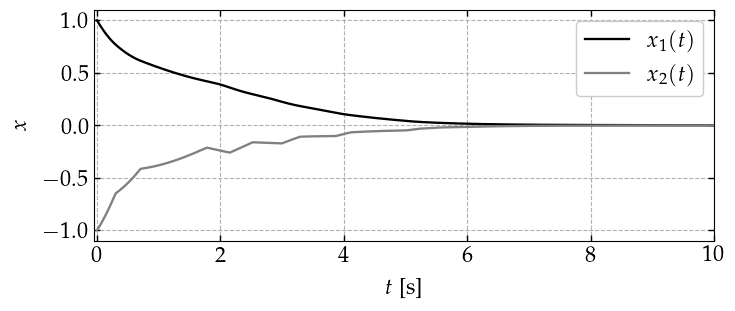

In [380]:
y = np.squeeze(np.array(plant_output)).T

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time_history,
    [y[0], y[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$',
    x_unit='s',
    x_use_prefixes=True,
    ylabel=fr'$x$',
    cfg={**cfg, 'style': {'color': ['black', 'gray']}},
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

(<matplotlib.lines.Line2D at 0x19e9a42ad50>,
 <matplotlib.lines.Line2D at 0x19e9a42ae90>)

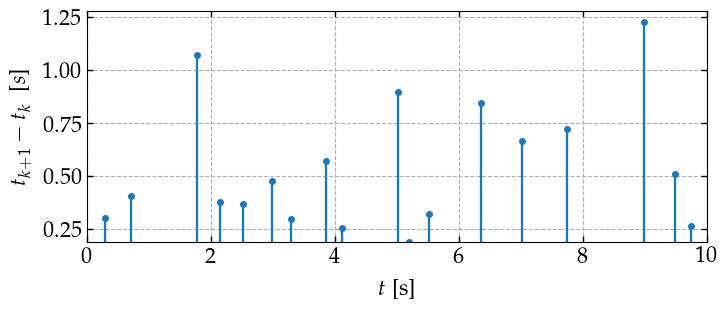

In [381]:
fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))

gph.stem(
    axs['iet'], event_time[1:], inter_event_time,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time_history[-1]),
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': time_history[-1]},
         'style': {'color': colors_list[0]}})

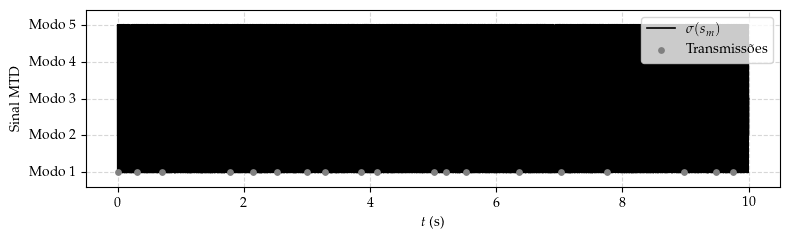

In [382]:
import numpy as np
import matplotlib.pyplot as plt


def plot_mtd_schedule(sampling_time, mode_history, event_time, cfg_dict=None):
  """
  Plota de forma 100% automatizada o histórico de chaveamento do MTD e as transmissões.
  Funciona para qualquer quantidade de modos (M) de forma dinâmica.
  """
  # 1. Recupera/filtra de forma vetorizada os modos nos instantes de transmissão
  event_mode_history = []
  if len(event_time) > 0:
    for t_ev in event_time:
      idx = np.argmin(np.abs(sampling_time - t_ev))
      event_mode_history.append(mode_history[idx])
  event_mode_history = np.array(event_mode_history)

  # 2. Identifica dinamicamente o número total de modos com base nos dados
  # (Adiciona suporte automático para qualquer valor de M)
  max_mode_idx = int(np.max(mode_history))
  modos_disponiveis = list(range(1, max_mode_idx + 2))
  labels_modos = [f'Modo {m}' for m in modos_disponiveis]

  # 3. Configuração do Mosaico (Mantendo o seu padrão estético)
  fig, axs = plt.subplot_mosaic([['mode']], figsize=(8, 2.5))

  # 4. Plot em formato de degrau (step) - Relógio cheio (7500 pontos)
  axs['mode'].step(
      sampling_time, mode_history + 1,
      where='post',
      color='black',
      linewidth=1.2,
      label=r'$\sigma(s_m)$'
  )

  # 5. Plot dos marcadores de transmissão (scatter) - Apenas instantes de evento (313 pontos)
  if len(event_time) > 0:
    axs['mode'].scatter(
        event_time, event_mode_history + 1,
        color='gray',
        s=15,
        zorder=3,
        label='Transmissões'
    )

  # --- Customização Estrita e Automática para Padrão de Artigo (IEEE) ---
  axs['mode'].set_yticks(modos_disponiveis)
  axs['mode'].set_yticklabels(labels_modos)

  # Define limites elásticos verticais automáticos para os degraus nunca colarem nas bordas
  axs['mode'].set_ylim(0.6, len(modos_disponiveis) + 0.4)

  axs['mode'].set_xlabel('$t$ (s)')
  axs['mode'].set_ylabel('Sinal MTD')
  axs['mode'].grid(True, linestyle='--', alpha=0.5)
  axs['mode'].legend(loc='upper right')

  # Aplica configurações estéticas extras do seu dicionário 'cfg' global se ele existir
  if cfg_dict and 'style' in cfg_dict:
    if 'title' in cfg_dict:
      axs['mode'].set_title(cfg_dict['title'])

  plt.tight_layout()
  plt.show()


# ==============================================================================
# COMO CHAMAR NA SUA CÉLULA DE EVENTOS:
# ==============================================================================
# Basta invocar a função passando os vetores resultantes da simulação:
plot_mtd_schedule(sampling_time, mode_history, event_time)